In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [5]:
NUM_CLUSTERS = 50
index_points = []



list_of_points = []
for c in range(NUM_CLUSTERS):
    x_cluster = np.random.uniform(-100,100)
    y_cluster = np.random.uniform(-100,100)

    for i in range(2000):
        list_of_points.append(np.random.multivariate_normal([x_cluster,y_cluster,0], [[1,0,0],[0,1,0],[0,0,3]]))
        index_points.append(c)
points = np.array(list_of_points)
points_x = points[:,0]
points_y = points[:,1]
points_z = points[:,2]

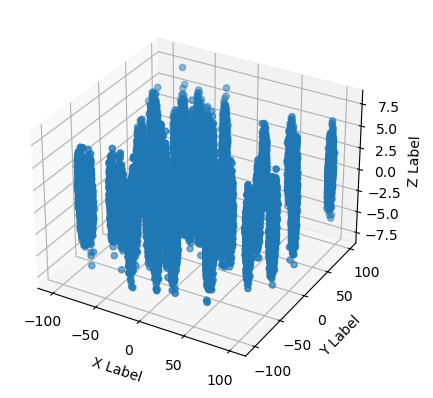

In [6]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(points_x, points_y, points_z)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()


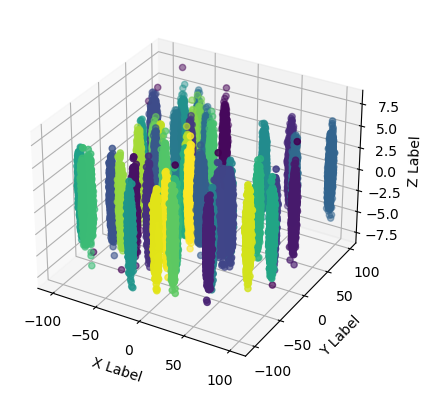

In [7]:
from sklearn.cluster import DBSCAN
from matplotlib import colormaps

clustering = DBSCAN(eps=2, min_samples=3).fit(points)
clustering.labels_

fig = plt.figure()
ax = fig.add_subplot(projection='3d')


ax.scatter(points_x, points_y, points_z, c=clustering.labels_)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

In [8]:
import pandas as pd

df = pd.DataFrame()
df["x"] = points_x
df["y"] = points_y
df["z"] = points_z
#df["cluster"] = np.array(index_points)


df_index = list(range(len(df)))
np.random.shuffle(df_index)
df = df.iloc[df_index]
df 
df.to_csv("random_points_clusters.csv", index=False)

In [9]:
from sklearn.metrics import rand_score

rand_score(index_points, clustering.labels_)

0.9935979199791998